A matrix:
[[ 1.       0.       0.      ...  0.       0.       0.     ]
 [-1.17612  2.43013 -1.17612 ...  0.       0.       0.     ]
 [ 0.      -1.17612  2.43013 ...  0.       0.       0.     ]
 ...
 [ 0.       0.       0.      ...  2.43013 -1.17612  0.     ]
 [ 0.       0.       0.      ... -1.17612  2.43013 -1.17612]
 [ 0.       0.       0.      ...  0.       0.       1.     ]]

F matrix:
[[0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.08 0.   ... 0.   0.   0.  ]
 [0.   0.   0.08 ... 0.   0.   0.  ]
 ...
 [0.   0.   0.   ... 0.08 0.   0.  ]
 [0.   0.   0.   ... 0.   0.08 0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]]
k-effective = 1.01171


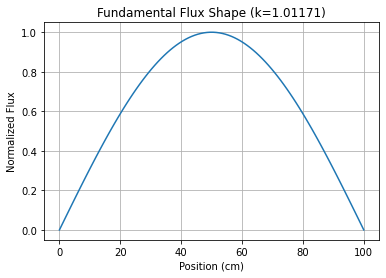

In [19]:
import numpy as np
import matplotlib.pyplot as plt

#1D Reactor homogeneus monogroup (slab)
# ------------------
# Problem parameters

L = 100.0          # cm
D = 1.2            # cm
Sigma_a = 0.07789     # 1/cm
nuSigma_f = 0.08   # 1/cm

N = 100

# ------------------
# Mesh

x = np.linspace(0, L, N)

dx = x[1] - x[0]

# ------------------
# Matrices

A = np.zeros((N, N))
F = np.zeros((N, N))

# ------------------
# Interior nodes

for i in range(1, N-1):

    A[i, i-1] = -D/dx**2

    A[i, i] = (2*D/dx**2 + Sigma_a)

    A[i, i+1] = -D/dx**2

    F[i, i] = nuSigma_f

# ------------------
# Boundary conditions
# phi(0)=0
# phi(L)=0

A[0,0] = 1.0
A[-1,-1] = 1.0

# No fission at boundary nodes

F[0,0] = 0.0
F[-1,-1] = 0.0

print("A matrix:")
print(A)

print("\nF matrix:")
print(F)

#Ec. de autovalores a resolver A−1Fϕ=kϕ A−1F=M

M = np.linalg.inv(A) @ F

#Autovalores y autovectores

eigvals, eigvecs = np.linalg.eig(M)

#Busco el mayor que corresponde al modo fundamental y a nuestro k efectivo y flujo

idx = np.argmax(eigvals.real)
k = eigvals[idx].real
print(f"k-effective = {k:.5f}")

phi = eigvecs[:, idx].real
phi = np.abs(phi) #puede que corresponda al autovalor negativo
phi = phi / np.max(phi) #normalizo

plt.plot(x, phi)

plt.xlabel("Position (cm)")
plt.ylabel("Normalized Flux")
plt.title(f"Fundamental Flux Shape (k={k:.5f})")

plt.grid(True)

plt.show()

In [20]:
#Defino funcion que resuelve el flujo, k

def solve_reactor(L, D, Sigma_a, nuSigma_f, N):

    x = np.linspace(0, L, N)
    dx = x[1] - x[0]

    A = np.zeros((N, N))
    F = np.zeros((N, N))

    # Interior nodes
    for i in range(1, N-1):

        A[i, i-1] = -D/dx**2
        A[i, i]   = 2*D/dx**2 + Sigma_a
        A[i, i+1] = -D/dx**2

        F[i, i] = nuSigma_f

    # Boundary conditions
    A[0,0] = 1
    A[-1,-1] = 1

    # Eigenvalue problem
    M = np.linalg.inv(A) @ F

    eigvals, eigvecs = np.linalg.eig(M)

    idx = np.argmax(eigvals.real)

    k = eigvals[idx].real

    phi = eigvecs[:, idx].real

    if phi[N//2] < 0:
        phi = -phi

    phi /= np.max(phi)

    return x, phi, k

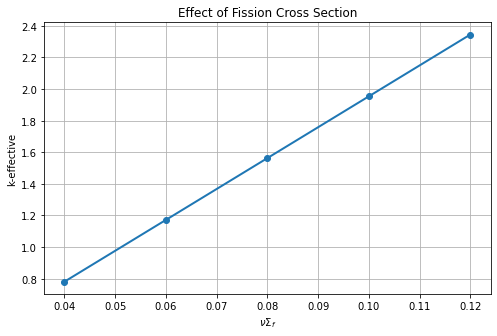

In [21]:
#Variacion de nuSigmaf

import matplotlib.pyplot as plt

L = 100
D = 1.2
Sigma_a = 0.05
N = 100

nuSigma_f_values = [0.04,0.06,0.08,0.10,0.12]

k_values = []

for nuSigma_f in nuSigma_f_values:

    x, phi, k = solve_reactor(L, D,Sigma_a,nuSigma_f, N)

    k_values.append(k)

plt.figure(figsize=(8,5))

plt.plot(nuSigma_f_values,k_values,"o-",linewidth=2)

plt.xlabel(r"$\nu\Sigma_f$")
plt.ylabel("k-effective")
plt.title("Effect of Fission Cross Section")

plt.grid(True)

plt.show()

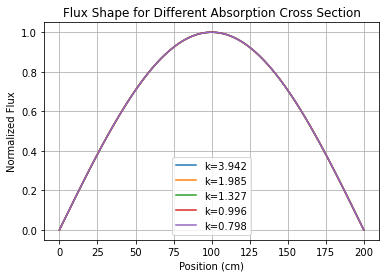

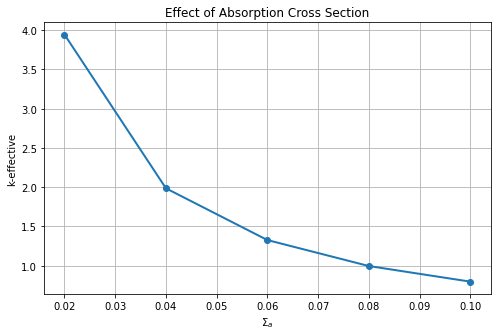

In [30]:
#Variacion de Sigmaabs
Sigma_a_values = [0.02,0.04,0.06,0.08,0.10]

k_values = []

for Sigma_a in Sigma_a_values:

    x, phi, k = solve_reactor(L,D,Sigma_a,0.08,N)

    k_values.append(k)
    plt.plot(x,phi,label=f"k={k:.3f}")
    
plt.xlabel("Position (cm)")
plt.ylabel("Normalized Flux")
plt.title("Flux Shape for Different Absorption Cross Section")

plt.legend()
plt.grid(True)

plt.show()  

plt.figure(figsize=(8,5))

plt.plot(Sigma_a_values,k_values,"o-",linewidth=2)

plt.xlabel(r"$\Sigma_a$")
plt.ylabel("k-effective")
plt.title("Effect of Absorption Cross Section")

plt.grid(True)

plt.show()

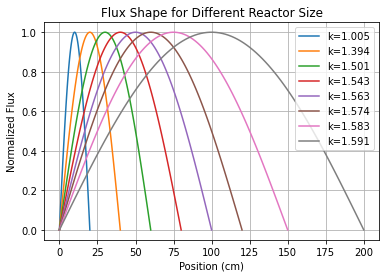

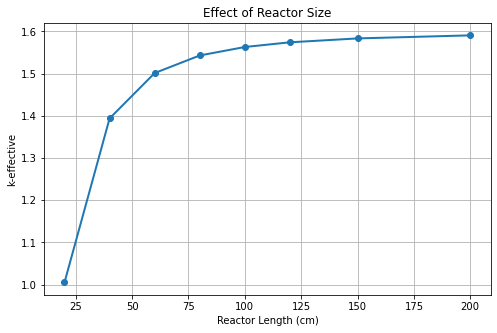

In [29]:
#Variacion del tamaño del reactor
lengths = [20,40,60,80,100,120,150,200]

k_values = []

for L in lengths:

    x, phi, k = solve_reactor(L, D,0.05,0.08,N)

    k_values.append(k)
    
    plt.plot(x,phi,label=f"k={k:.3f}")
    
plt.xlabel("Position (cm)")
plt.ylabel("Normalized Flux")
plt.title("Flux Shape for Different Reactor Size")

plt.legend()
plt.grid(True)

plt.show()  

plt.figure(figsize=(8,5))

plt.plot(lengths,k_values,"o-",linewidth=2)

plt.xlabel("Reactor Length (cm)")
plt.ylabel("k-effective")
plt.title("Effect of Reactor Size")

plt.grid(True)

plt.show()

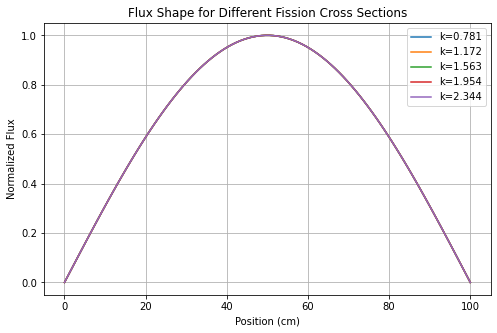

In [26]:
plt.figure(figsize=(8,5))

for nuSigma_f in [0.04,0.06,0.08,0.10,0.12]:

    x, phi, k = solve_reactor(
        L=100,
        D=1.2,
        Sigma_a=0.05,
        nuSigma_f=nuSigma_f,
        N=100
    )

    plt.plot(
        x,
        phi,
        label=f"k={k:.3f}"
    )

plt.xlabel("Position (cm)")
plt.ylabel("Normalized Flux")
plt.title("Flux Shape for Different Fission Cross Sections")

plt.legend()
plt.grid(True)

plt.show()